In [40]:
import numpy as np

import tigramite
from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI

from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler
import pandas as pd
from matplotlib import pyplot as plt

In [31]:
N_MODES = 4
TAU_MAX = 5
LAT = 40
LON = 40
N_SAMPLES = 995

In [ ]:
# Step 1: Load the data
mlp_output = np.load("../outputs/test_results-2025_07_01_19_03_57.npz")

In [24]:
# Step 2:Reshape the data
# targets = mlp_output["target"].reshape(4975, 1600) # 995 samples, 5 time steps, 40x40 spatial dimensions
predictions = mlp_output["outputs"].reshape(N_SAMPLES, TAU_MAX, LAT, LON) # reshape from 995x8000

In [33]:
 # Step 3: Reduce spatial dimensions to 4 modes using PCA

# Flatten spatial dimensions for PCA
flattened = predictions.reshape(N_SAMPLES * TAU_MAX, LAT * LON)

# Standardize the data
scaler = StandardScaler()
flattened_scaled = scaler.fit_transform(flattened)

# Apply PCA to reduce to 4 modes
pca = PCA(n_components=N_MODES)
reduced = pca.fit_transform(flattened_scaled)

# Reshape back to temporal format: (995, 5, 4)
reduced_temporal = reduced.reshape(N_SAMPLES, TAU_MAX, N_MODES)
data_reshaped = reduced_temporal.reshape(-1, N_MODES)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {np.sum(pca.explained_variance_ratio_):.3f}")
print(f"Reduced data shape: {reduced_temporal.shape}")
print(f"Data reshaped shape: {data_reshaped.shape}")

PCA explained variance ratio: [0.18631315 0.10114242 0.06925502 0.03520994]
Total explained variance: 0.392
Reduced data shape: (995, 5, 4)
Data reshaped shape: (4975, 4)


In [35]:
# STEP 4: Learn causal graph using PCMCI+

# Create variable names for the modes
var_names = [f"mode_{i}" for i in range(N_MODES)]
dataframe = pp.DataFrame(data_reshaped, var_names=var_names)

# Initialize PCMCI+
pcmci = PCMCI(
    dataframe=dataframe,
    cond_ind_test=ParCorr(),
    verbosity=2
)

# Run PCMCI+
results = pcmci.run_pcmci(
    tau_max=TAU_MAX,  # Maximum time lag
    pc_alpha=0.05  # Significance level
)

# Extract results
graph = results['graph']
val_matrix = results['val_matrix']
p_matrix = results['p_matrix']

print(f"\nPCMCI+ Results:")
print(f"Graph shape: {graph.shape}")
print(f"Value matrix shape: {val_matrix.shape}")
print(f"P-value matrix shape: {p_matrix.shape}")

# Print the discovered links
print(f"\nDiscovered causal links:")
for i in range(len(var_names)):
    for j in range(len(var_names)):
        for tau in range(TAU_MAX):
            if graph[i, j, tau] != "":
                print(f"{var_names[i]} <-{graph[i, j, tau]}- {var_names[j]} (lag {tau+1})")



##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 5
pc_alpha = [0.05]
max_conds_dim = None
max_combinations = 1



## Variable mode_0

Iterating through pc_alpha = [0.05]:

# pc_alpha = 0.05 (1/1):

Testing condition sets of dimension 0:

    Link (mode_0 -1) -?> mode_0 (1/20):
    Subset 0: () gives pval = 0.00000 / val =  0.892
    No conditions of dimension 0 left.

    Link (mode_0 -2) -?> mode_0 (2/20):
    Subset 0: () gives pval = 0.00000 / val =  0.884
    No conditions of dimension 0 left.

    Link (mode_0 -3) -?> mode_0 (3/20):
    Subset 0: () gives pval = 0.00000 / val =  0.842
    No conditions of dimension 0 left.

    Link (mode_0 -4) -?> mode_0 (4/20):
    Subset 0: () gives pval = 0.00000 / val =  0.859
    No conditions of dimension 0 left.

    Link (mode_0 -5) -?> mode_0 (5/20):
    Subset 0: () gives pval = 0.00000 / val =  0.770
    No conditions of dimension 0 left.

    Link (mode_1 -

In [38]:
# Step 5: Analyze mode relationships


print(f"\nStep 5: Analyzing mode relationships...")

# Calculate correlations between modes
correlations = np.corrcoef(reduced_temporal.reshape(-1, 4).T)

print(f"\nCorrelation matrix between modes:")
print(pd.DataFrame(correlations, index=var_names, columns=var_names))

# Count causal links per mode
print(f"\nCausal link counts per mode:")
for i, mode in enumerate(var_names):
    incoming = np.sum(graph[i, :, :] != "")
    outgoing = np.sum(graph[:, i, :] != "")
    print(f"{mode}: {incoming} incoming, {outgoing} outgoing links")



Step 5: Analyzing mode relationships...

Correlation matrix between modes:
              mode_0        mode_1        mode_2        mode_3
mode_0  1.000000e+00 -6.664936e-09  1.291938e-08  2.519600e-09
mode_1 -6.664936e-09  1.000000e+00  1.835904e-07 -9.360850e-09
mode_2  1.291938e-08  1.835904e-07  1.000000e+00 -1.007753e-09
mode_3  2.519600e-09 -9.360850e-09 -1.007753e-09  1.000000e+00

Causal link counts per mode:
mode_0: 20 incoming, 21 outgoing links
mode_1: 20 incoming, 22 outgoing links
mode_2: 20 incoming, 20 outgoing links
mode_3: 22 incoming, 19 outgoing links



Step 6: Plotting causal graph...


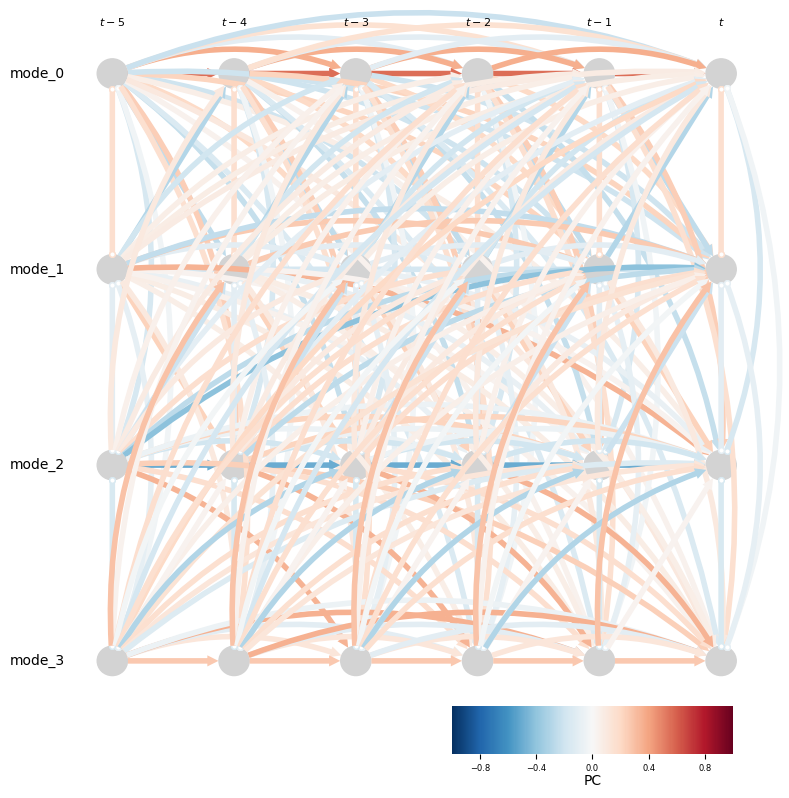

In [58]:
# Step 6: Plot causal graph
print(f"\nStep 6: Plotting causal graph...")

# Plot graph for each lag
tp.plot_time_series_graph(
    graph = graph,
    val_matrix=val_matrix,
    figsize=(8, 8),
    node_size=0.05,
    var_names=var_names,
    link_colorbar_label='PC')

plt.tight_layout()
# plt.savefig("causal_graph_example.png", dpi=300, bbox_inches='tight')
plt.show()